In [2]:
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

## Superoperator analysis from .npz files: $h$-sweep for different $\alpha$

In [3]:
# (npz-number, alpha)

file_numbers = [(11, .25),
                (12, .50),
                (13, .75),
                (14, 1.)]

suffix = '_normalized'

In [4]:
frames = []
N_sweeps = len(file_numbers)

for nbr, alpha in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["alpha"] = alpha

    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
alpha_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

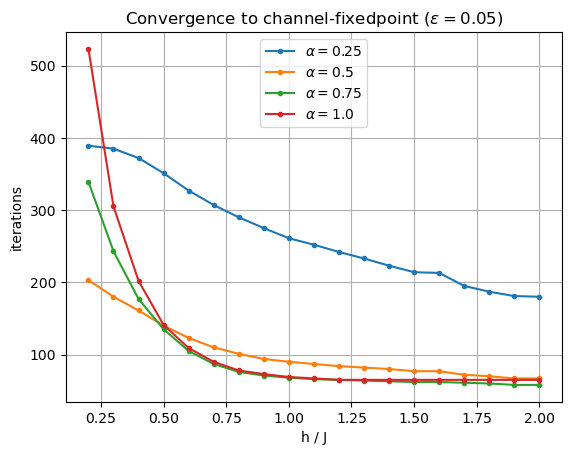

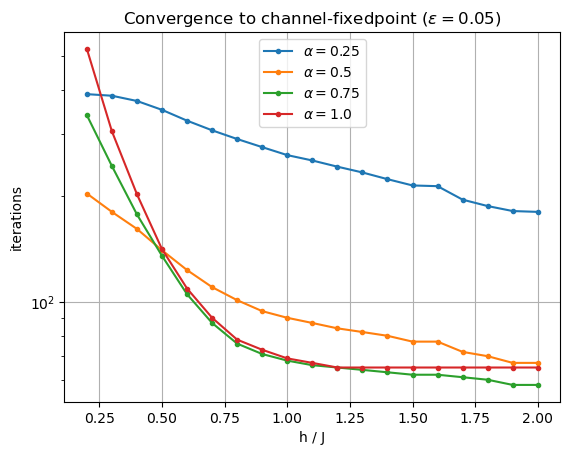

In [5]:
for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.plot(x, y0, label=rf"$\alpha = {alpha_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.semilogy(x, y0, label=rf"$\alpha = {alpha_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

'\nlabels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]\nymin, ymax = 0., 0.05\npos=[[0,0],[0,1],[1,0],[1,1]]\n\nfig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)\n\n\nfor i, sigma in enumerate(ha_data["alpha"].unique()):\n    ax = axs[pos[i][0], pos[i][1]]\n    subset = ha_data[ha_data["alpha"] == sigma].sort_values("h_over_J")\n\n    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)\n\n    ax.set_title(rf"$\x07lpha = {sigma}$")\n    ax.set_xlabel("h / J")\n    ax.set_ylabel(r"$\\Delta_2$")\n    ax.legend(title=r"$\x07lpha$")\n    ax.set_ylim(ymin, ymax)\n\n    ax.set_xticks(ticks[1::2])\n    ax.set_xticklabels(labels[1::2])\n    plt.tight_layout()\nplt.show()\n'

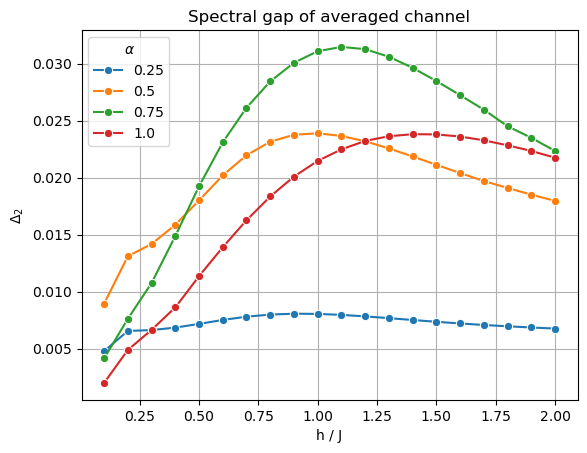

In [6]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", marker="o", palette="tab10")

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\alpha$")
plt.grid(True)
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

'''
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.05
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, sigma in enumerate(ha_data["alpha"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["alpha"] == sigma].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)

    ax.set_title(rf"$\alpha = {sigma}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\alpha$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()
'''

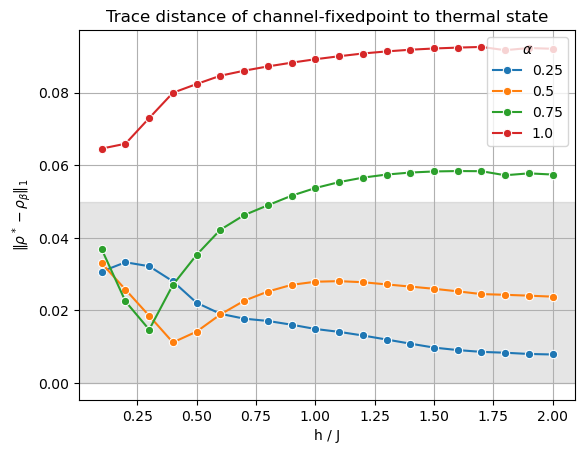

In [7]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", marker="o", palette="tab10")


ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\alpha$", loc=1)
plt.grid(True)
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")

## Superoperator analysis from .npz files: $h$-sweep for different $\sigma$

In [38]:
# (npz-number, alpha)

file_numbers = [(15, .5),
                (16, 1.),
                (17, 2.),
                (18, 4.),
                (19, 3.)]

suffix = '_sigma'

In [39]:
frames = []
N_sweeps = len(file_numbers)

for nbr, sigma in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["sigma"] = sigma
    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
sigma_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

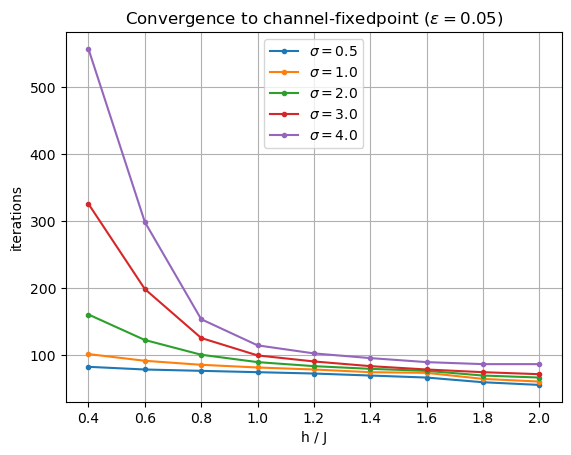

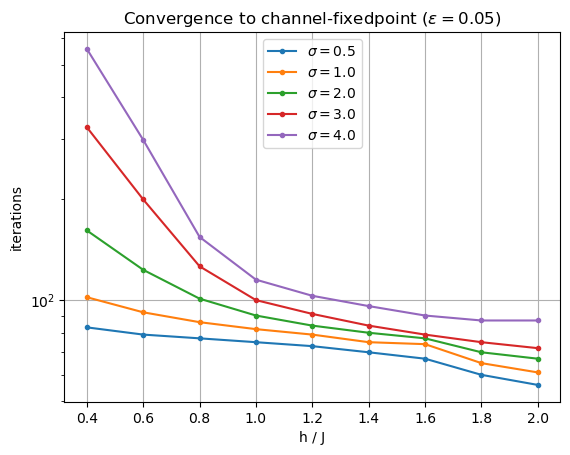

In [40]:
for sigma_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, sigma_idx]
    plt.plot(x, y0, label=rf"$\sigma = {sigma_vals[sigma_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for sigma_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, sigma_idx]
    plt.semilogy(x, y0, label=rf"$\sigma = {sigma_vals[sigma_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.gca()
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

'\nlabels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]\nymin, ymax = 0., 0.05\npos=[[0,0],[0,1],[1,0],[1,1]]\n\nfig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)\n\n\nfor i, sigma in enumerate(ha_data["sigma"].unique()):\n    ax = axs[pos[i][0], pos[i][1]]\n    subset = ha_data[ha_data["sigma"] == sigma].sort_values("h_over_J")\n\n    sns.barplot(data=subset, x="h_over_J", y="Delta2", ax=ax)\n\n    ax.set_title(rf"$\\sigma = {sigma}$")\n    ax.set_xlabel("h / J")\n    ax.set_ylabel(r"$\\Delta_2$")\n    ax.legend(title=r"$\\sigma$")\n    ax.set_ylim(ymin, ymax)\n\n    ax.set_xticks(ticks[1::2])\n    ax.set_xticklabels(labels[1::2])\n    plt.tight_layout()\nplt.show()\n'

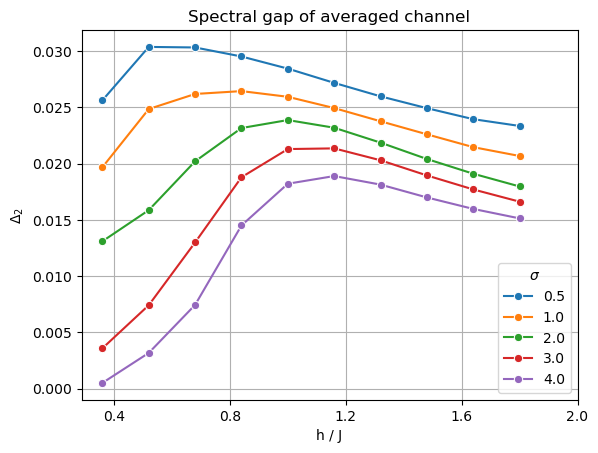

In [41]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="sigma", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="Delta2", hue="sigma", marker="o", palette="tab10")


ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

ax.set_xticks(ticks[1::2])
ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\sigma$")
plt.grid(True)
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

'''
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.05
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, sigma in enumerate(ha_data["sigma"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["sigma"] == sigma].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", ax=ax)

    ax.set_title(rf"$\sigma = {sigma}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\sigma$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()
'''

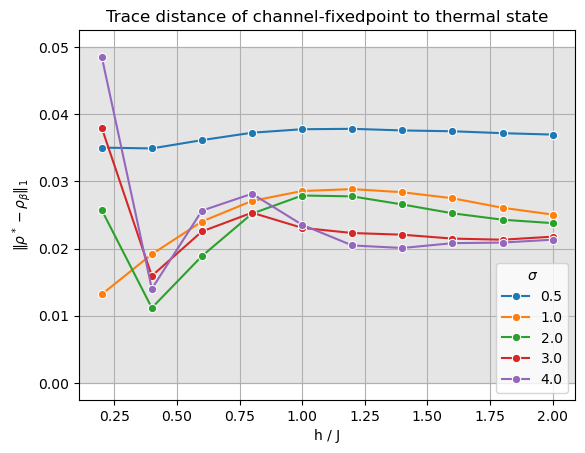

In [42]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="sigma", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="sigma", marker="o", palette="tab10")

ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\sigma$")
plt.grid(True)
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")

## Superoperator analysis from .npz files: $\beta$-sweep

In [97]:
file_numbers = [(21, .25), (24, .35), (20, .5),(22, .75),(23, 1.)]
file_numbers = sorted(file_numbers, key=lambda pair: pair[1])
suffix = '_beta'

frames = []
N_sweeps = len(file_numbers)

for nbr, alpha in file_numbers:
    path = Path(f"data/superoperator_N4_beta_sweep_{nbr}.npz")  
    data = np.load(path)

    df = pd.DataFrame({
        "beta": data["beta"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["alpha"] = alpha
    frames.append(df)

beta_data = pd.concat(frames, ignore_index=True)
beta_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   beta            100 non-null    float64
 1   Delta2          100 non-null    float64
 2   Delta_th        100 non-null    float64
 3   num_closer      100 non-null    int64  
 4   trace_distance  100 non-null    float64
 5   get_mixingtime  100 non-null    float64
 6   alpha           100 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 5.6 KB


In [98]:
betas = beta_data["beta"].drop_duplicates().to_numpy()
iterations = beta_data.pivot_table(index="alpha", columns="beta", values="get_mixingtime").to_numpy()
gap = beta_data.pivot_table(index="alpha", columns="beta", values="Delta2").to_numpy()
dist_to_gibbs = beta_data.pivot_table(index="alpha", columns="beta", values="trace_distance").to_numpy()

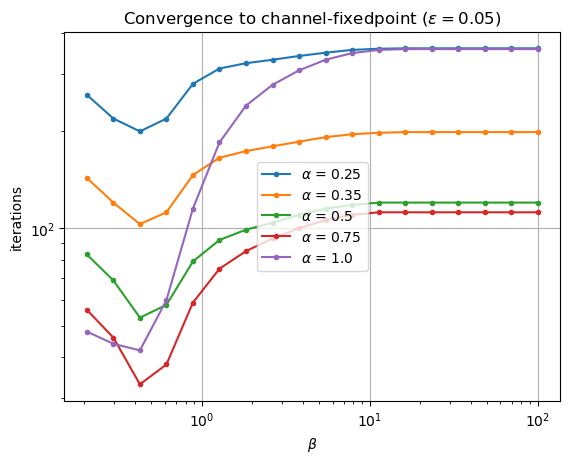

In [99]:
for i in range(len(file_numbers)):
    plt.loglog(betas[2:], iterations[i][2:], marker=".", label = rf"$\alpha$ = {file_numbers[i][1]}")

plt.legend(loc="center")
plt.xlabel(rf"$\beta$")
plt.ylabel("iterations")
plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
plt.grid(True)
plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

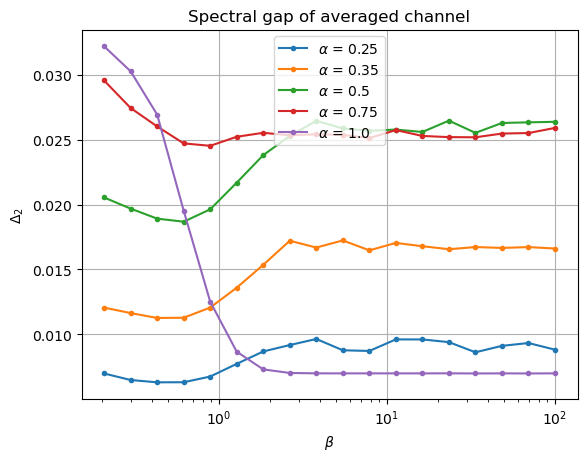

In [100]:
for i in range(len(file_numbers)):
    plt.semilogx(betas[2:], gap[i][2:], marker=".", label = rf"$\alpha$ = {file_numbers[i][1]}")

plt.legend(loc="upper center")
plt.xlabel(rf"$\beta$")
plt.ylabel(rf"$\Delta_2$")
plt.title(rf"Spectral gap of averaged channel")
plt.grid(True)
plt.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

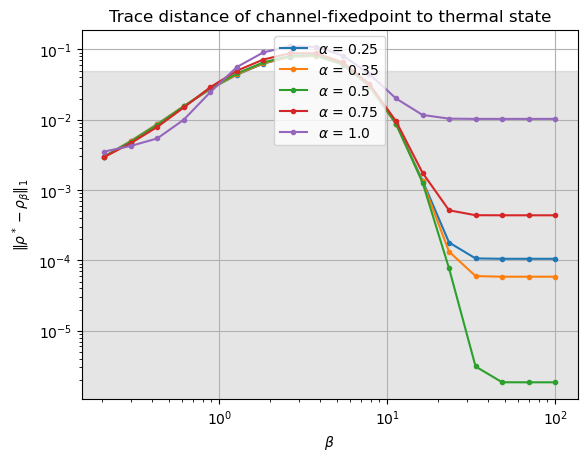

In [101]:
for i in range(len(file_numbers)):
    plt.loglog(betas[2:], dist_to_gibbs[i][2:], marker=".", label = rf"$\alpha$ = {file_numbers[i][1]}")


plt.axhspan(0, 0.05, color="gray", alpha=0.2)
plt.legend(loc="upper center")
plt.xlabel(rf"$\beta$")
plt.ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
plt.title("Trace distance of channel-fixedpoint to thermal state")
plt.grid(True)
plt.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

## Grid

In [3]:
nbr = 1
path = Path(f"data/grid/superoperator_N4_grid_{nbr}.npz")  
data = np.load(path)

In [24]:
print(data.files)
for col in data.keys():
    print(col, np.shape(data[col]))
h = data["h"]

['h', 'alpha', 'sigma', 'omega_max', 'beta', 'h_over_J', 'eigvals', 'Delta2', 'Delta_th', 'num_closer', 'trace_distance', 'get_mixingtime', 'channels']
h (600,)
alpha (600,)
sigma (600,)
omega_max (600,)
beta (600,)
h_over_J (600,)
eigvals (600, 8)
Delta2 (600,)
Delta_th (600,)
num_closer (600,)
trace_distance (600,)
get_mixingtime (600,)
channels (0,)


In [27]:
h_vals = np.unique(data["h"])
alpha_vals = np.unique(data["alpha"])
sigma_vals = np.unique(data["sigma"])
omega_vals = np.unique(data["omega_max"])

shape = (len(h_vals), len(alpha_vals), len(sigma_vals), len(omega_vals))

Delta2 = np.full(shape, np.nan)
trace_distance = np.full(shape, np.nan)
mixingtime = np.full(shape, np.nan)

h_index = {v: i for i, v in enumerate(h_vals)}
alpha_index = {v: i for i, v in enumerate(alpha_vals)}
sigma_index = {v: i for i, v in enumerate(sigma_vals)}
omega_index = {v: i for i, v in enumerate(omega_vals)}

for i in range(len(data["h"])):
    idx = (
        h_index[data["h"][i]],
        alpha_index[data["alpha"][i]],
        sigma_index[data["sigma"][i]],
        omega_index[data["omega_max"][i]],
    )
    Delta2[idx] = data["Delta2"][i]
    trace_distance[idx] = data["trace_distance"][i]
    mixingtime[idx] = data["get_mixingtime"][i]

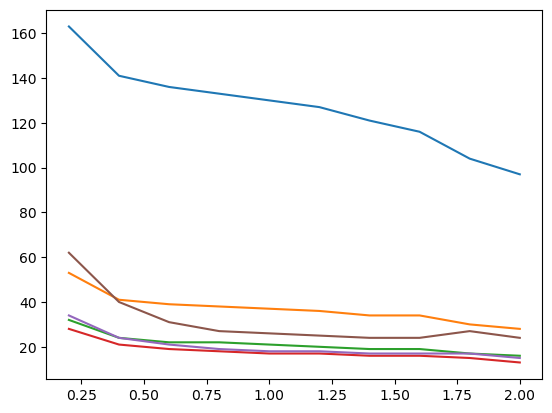

In [33]:
for i in range(np.shape(mixingtime)[1]):
    X = h_vals
    Y = [mixingtime[j, i, 0, 0] for j in range(len(X))]
    plt.plot(X,Y)

## $\beta$ sweep

In [84]:
nbr = [26, 27]

beta_vals = [None] * len(nbr)
Delta2 = [None] * len(nbr)
trace_distance = [None] * len(nbr)
mixingtime = [None] * len(nbr)

for k, n in enumerate(nbr):
    path = Path(f"data/superoperator_N4_sweep_{n}.npz")  
    data = np.load(path)

    print(data.files)
    for col in data.keys():
        print(col, np.shape(data[col]))

    beta_vals[k] = np.unique(data["beta"])


    Delta2[k] = np.zeros_like(beta_vals[k])
    trace_distance[k] = np.zeros_like(beta_vals[k])
    mixingtime[k] = np.zeros_like(beta_vals[k])

    h_index = {v: i for i, v in enumerate(beta_vals[k])}

    for i in range(len(beta_vals[k])): 
        Delta2[k][i] = data["Delta2"][i]
        trace_distance[k][i] = data["trace_distance"][i]
        mixingtime[k][i] = data["get_mixingtime"][i]


['beta', 'channels', 'eigvals', 'Delta2', 'Delta_th', 'num_closer', 'trace_distance', 'get_mixingtime']
beta (50,)
channels (0,)
eigvals (50, 8)
Delta2 (50,)
Delta_th (50,)
num_closer (50,)
trace_distance (50,)
get_mixingtime (50,)
['beta', 'channels', 'eigvals', 'Delta2', 'Delta_th', 'num_closer', 'trace_distance', 'get_mixingtime']
beta (50,)
channels (0,)
eigvals (50, 8)
Delta2 (50,)
Delta_th (50,)
num_closer (50,)
trace_distance (50,)
get_mixingtime (50,)


In [86]:
print(mixingtime[0])

[ 67. 120. 140. 148. 153. 157. 160. 163. 165. 167. 168. 170. 171. 172.
 173. 173. 174. 175. 175. 175. 176. 176. 176. 177. 177. 177. 177. 177.
 177. 177. 177. 177. 177. 178. 178. 178. 178. 178. 178. 178. 178. 178.
 178. 178. 178. 178. 178. 178. 178. 178.]


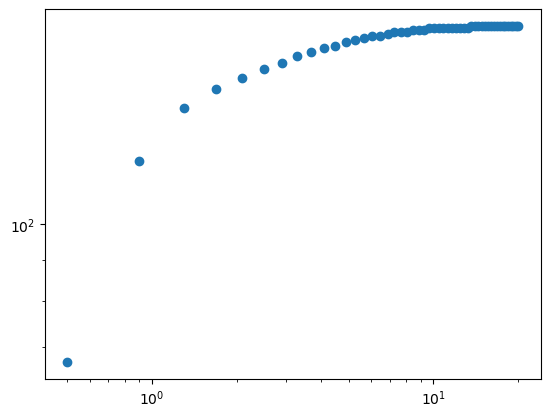

In [88]:
for i in range(1):
    plt.scatter(beta_vals[i], mixingtime[i])
    plt.xscale('log')
    plt.yscale('log')
plt.show()


[ 0.5         0.89795918  1.29591837  1.69387755  2.09183673  2.48979592
  2.8877551   3.28571429  3.68367347  4.08163265  4.47959184  4.87755102
  5.2755102   5.67346939  6.07142857  6.46938776  6.86734694  7.26530612
  7.66326531  8.06122449  8.45918367  8.85714286  9.25510204  9.65306122
 10.05102041 10.44897959 10.84693878 11.24489796 11.64285714 12.04081633
 12.43877551 12.83673469 13.23469388 13.63265306 14.03061224 14.42857143
 14.82653061 15.2244898  15.62244898 16.02040816 16.41836735 16.81632653
 17.21428571 17.6122449  18.01020408 18.40816327 18.80612245 19.20408163] [241. 530. 782. 886. 919. 928. 929. 931. 931. 931. 931. 931. 931. 931.
 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931.
 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931. 931.
 931. 931. 931. 931. 931. 931.]


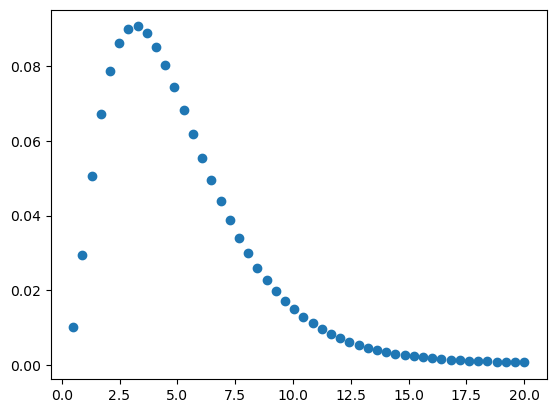

In [81]:
print(beta_vals[1], mixingtime[1])

plt.scatter(beta_vals[0], trace_distance[0])
plt.show()

In [77]:
from scipy.optimize import curve_fit

def fit_func(x, a, b, c, d):
    #c, d = -0.5, 1.5
    return a + b * (x**c) * np.power(np.log(x), d)


x = np.asarray(beta_vals[0], dtype=float)
y = np.asarray(mixingtime[0], dtype=float)


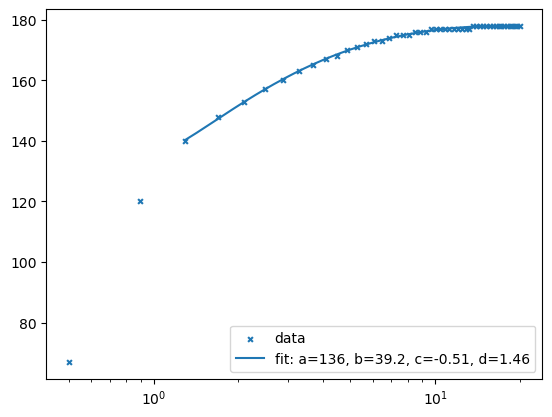

In [78]:
fit_mask = np.isfinite(x) & np.isfinite(y) & (y > 0) & (x > 1)
fit_x = x[fit_mask]
fit_y = y[fit_mask]

popt, pcov = curve_fit(
    fit_func,
    fit_x,
    fit_y,
    p0=(1.0, 800.0, -0.5, 1.5),
    bounds=([0.0, 0.0, -10, -10.0], [1000., 1000., 10.0, 10.]),

    method="trf",
    max_nfev=5000,
)

xfit = np.linspace(fit_x.min(), fit_x.max(), 300)

plt.scatter(x, y, label="data", s=12, marker='x')
plt.plot(xfit, fit_func(xfit, *popt), label=f"fit: a={popt[0]:.3g}, b={popt[1]:.3g}, c={popt[2]:.3g}, d={popt[3]:.3g}")
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()


In [45]:
print()